# 2.2 通过极简方案实现数字识别任务

上一节介绍了创新性的“横纵式”教学法，有助于深度学习初学者快速掌握深度学习理论知识，并在过程中让读者获得真实建模的实战体验。在“横纵式”教学法中，纵向概要介绍模型的基本代码结构和极简实现方案，如 **图1** 所示。本节将使用这种极简实现方案快速完成手写数字识别的建模。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/dd8d51f8ae634666934841d7fe797a0cda6c8f0ed4434448aafd2ce6082302ff" width="1000" hegiht="" ></center>
<center><br>图1：“横纵式”教学法—纵向极简实现方案</br></center>
<br></br>


在数据处理前，首先要加载飞桨平台与“手写数字识别”模型相关的类库，实现方法如下。

魔数: 2051, 图像数量: 60000, 尺寸: 28x28
魔数: 2049, 标签数量: 60000
(28, 28)
5


<Figure size 640x480 with 0 Axes>

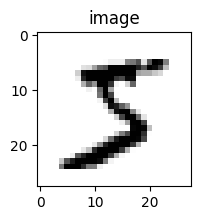

图像数据形状和对应数据为: (28, 28)
图像标签形状和对应数据为: () 5

打印第一个batch的第一个图像，对应标签数字为5


In [82]:
import struct
import numpy as np
import os
import matplotlib.pyplot as plt

def read_mnist_images(file_path):
    """读取MNIST图像文件"""
    with open(file_path, 'rb') as f:
        # 解析文件头
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        print(f"魔数: {magic}, 图像数量: {num_images}, 尺寸: {rows}x{cols}")
        
        # 读取所有像素数据
        data = np.frombuffer(f.read(), dtype=np.uint8)
        # 重塑为 [num_images, rows, cols]
        images = data.reshape(num_images, rows, cols)
        return images

def read_mnist_labels(file_path):
    """读取MNIST标签文件"""
    with open(file_path, 'rb') as f:
        # 解析文件头
        magic, num_labels = struct.unpack('>II', f.read(8))
        print(f"魔数: {magic}, 标签数量: {num_labels}")
        
        # 读取所有标签数据
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

train_dataset = read_mnist_images("./work/2.1data/train-images-idx3-ubyte")
train_labels = read_mnist_labels("./work/2.1data/train-labels-idx1-ubyte")

tran_data_0 = train_dataset[0]
tran_label_0 = train_labels[0]


print(tran_data_0.shape)
# print(tran_data_0)
# print(tran_label_0.shape)
print(tran_label_0)

plt.figure("Image") # 图像窗口名称
plt.figure(figsize=(2,2))
plt.imshow(tran_data_0, cmap=plt.cm.binary)
plt.axis('on') # 关掉坐标轴为 off
plt.title('image') # 图像题目
plt.show()

print("图像数据形状和对应数据为:", tran_data_0.shape)
print("图像标签形状和对应数据为:", tran_label_0.shape, tran_label_0)
print("\n打印第一个batch的第一个图像，对应标签数字为{}".format(tran_label_0))


# # 显示第一batch的第一个图像

# plt.figure("Image") # 图像窗口名称
# plt.figure(figsize=(2,2))
# plt.imshow(train_data_0, cmap=plt.cm.binary)
# plt.axis('on') # 关掉坐标轴为 off
# plt.title('image') # 图像题目
# plt.show()


使用matplotlib工具包将其显示出来，如打印结果所示。可以看到图片显示的数字是5，和对应标签数字一致。
说明:飞桨将维度是28×28的手写数字图像转成向量形式存储，因此使用飞桨数据加载器读取到的手写数字图像是长度为784（28×28）的向量。

## 2.2.2 模型设计

在房价预测深度学习任务中，我们使用了单层且没有非线性变换的模型，取得了理想的预测效果。在手写数字识别中，我们依然使用这个模型预测输入的图形数字值。其中，模型的输入为784维（$28\times 28$）数据，输出为1维数据，如 **图4** 所示。

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/9c146e7d9c4a4119a8cd09f7c8b5ee61f2ac1820a221429a80430291728b9c4a" width="400" hegiht="" ></center>
<center><br>图4：手写数字识别网络模型</br></center>
<br></br>

输入像素的位置排布信息对理解图像内容非常重要（如将原始尺寸为$28\times 28$图像的像素按照$7\times 112$的尺寸排布，那么其中的数字将不可识别），因此网络的输入设计为$28\times 28$的尺寸，而不是$1\times 784$，以便于模型能够正确处理像素之间的空间信息。

------
**说明：**

事实上，采用只有一层的简单网络（对输入求加权和）时并没有处理位置关系信息，因此可以猜测出此模型的预测效果可能有限。在后续优化环节介绍的卷积神经网络则更好的考虑了这种位置关系信息，模型的预测效果也会有显著提升。

------

下面以类的方式组建手写数字识别的网络，实现方法如下所示。

Linear = 全连接层 = 就是做【加权求和】
就是把输入的数字，乘上一组权重，再加个偏置，输出新数字。

In [83]:
import torch
import torch.nn as nn

class MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 1)

    def forward(self, x):
        return self.fc(x)

model = MNIST()
x = torch.randn(1, 784)  # 模拟一张展平的MNIST图(1,784)
y = model(x)
print(y.shape)  # 输出: torch.Size([1, 1])

torch.Size([1, 1])


## 2.2.3 训练配置

训练配置需要先生成模型实例（设为“训练”状态），再设置优化算法和学习率（使用随机梯度下降，学习率设置为0.001），实现方法如下所示。
## 2.2.4 训练过程

训练过程采用二层循环嵌套方式，训练完成后需要保存模型参数，以便后续使用。

- 内层循环：负责整个数据集的一次遍历，遍历数据集采用分批次（batch）方式。
- 外层循环：定义遍历数据集的次数，本次训练中外层循环10次，通过参数EPOCH_NUM设置。

魔数: 2051, 图像数量: 60000, 尺寸: 28x28
魔数: 2049, 标签数量: 60000
(60000, 28, 28)
(60000,)
epoch 0, batch_id 0, loss 16.144079208374023
epoch 0, batch_id 1000, loss 8.656113624572754


/var/folders/pl/6trv_vt979ndkfx1gs8f64c80000gn/T/ipykernel_21018/3362633571.py:62: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(predict, label_normal, reduction='mean')


epoch 0, batch_id 2000, loss 7.560183048248291
epoch 0, batch_id 3000, loss 8.138792037963867
epoch 1, batch_id 0, loss 9.54435920715332
epoch 1, batch_id 1000, loss 11.164813995361328
epoch 1, batch_id 2000, loss 6.160506248474121
epoch 1, batch_id 3000, loss 7.1901326179504395
epoch 2, batch_id 0, loss 5.828935146331787
epoch 2, batch_id 1000, loss 11.84194564819336
epoch 2, batch_id 2000, loss 11.280189514160156
epoch 2, batch_id 3000, loss 11.08673095703125
epoch 3, batch_id 0, loss 8.659669876098633
epoch 3, batch_id 1000, loss 8.296430587768555
epoch 3, batch_id 2000, loss 7.812536239624023
epoch 3, batch_id 3000, loss 7.225419521331787
epoch 4, batch_id 0, loss 7.947314262390137
epoch 4, batch_id 1000, loss 7.964313983917236
epoch 4, batch_id 2000, loss 6.819283962249756
epoch 4, batch_id 3000, loss 8.996240615844727
epoch 5, batch_id 0, loss 11.934809684753418
epoch 5, batch_id 1000, loss 4.317696571350098
epoch 5, batch_id 2000, loss 8.65363883972168
epoch 5, batch_id 3000, lo

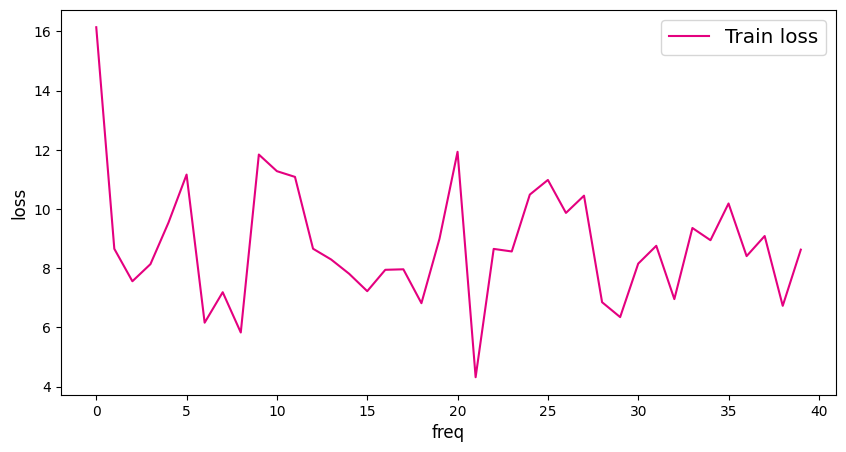

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn.functional as F
root_dir = './work/2.1data'
data_dir = root_dir + '/train-images-idx3-ubyte'
label_dir = root_dir + '/train-labels-idx1-ubyte'

model = MNIST()
image = read_mnist_images(data_dir)
label = read_mnist_labels(label_dir)
def norm_img(img) :
    # 检验传入数据格式是否正确，img的shape为[batch_size, 28, 28]
    assert len(img.shape) == 3
    batch_size, height, width = img.shape[0], img.shape[1], img.shape[2]
    # 归一化图片，将像素值从[0, 255]映射到[0, 1]
    img = img / 255.0
    img = img.reshape(batch_size, height * width)
    return img

#把数据和标签打包成一个数据集
class MNISTDataset(Dataset):
    def __init__(self, image, label):
        self.image = image
        self.label = label
    def __len__(self):
        return len(self.image)
    def __getitem__(self, idx):
        return self.image[idx], self.label[idx]

def plot(loss_list):
    plt.figure(figsize=(10,5))
    
    freqs = [i for i in range(len(loss_list))]
    # 绘制训练损失变化曲线
    plt.plot(freqs, loss_list, color='#e4007f', label="Train loss")
    
    # 绘制坐标轴和图例
    plt.ylabel("loss", fontsize='large')
    plt.xlabel("freq", fontsize='large')
    plt.legend(loc='upper right', fontsize='x-large')
    
    plt.show()

def train():
    print(image.shape)
    print(label.shape)
    train_dataset = MNISTDataset(image, label)
    # 加载训练集 batch_size 设为 16
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    opt = torch.optim.SGD(model.parameters(), lr=0.01)
    EPOCH_NUM = 10
    loss_list = []
    for epoch in range(EPOCH_NUM):
        for batch_id, data in enumerate(train_loader):
            image_normal = norm_img(data[0])
            label_normal = data[1].float().unsqueeze(1)
            #前向计算
            predict = model(image_normal)
            # 计算损失
            loss = F.mse_loss(predict, label_normal, reduction='mean')
            avg_loss = torch.mean(loss)

            if batch_id % 1000 == 0:
                loss = avg_loss.item()
                loss_list.append(loss)
                print('epoch {}, batch_id {}, loss {}'.format(epoch, batch_id, loss))
            # 反向传播
            
            avg_loss.backward()
            opt.step()
            opt.zero_grad()
    return loss_list

loss_list = train()
torch.save(model.state_dict(), './work/2.1data/mnist_model.pth')
plot(loss_list)




另外，从训练过程中损失所发生的变化可以发现，虽然损失整体上在降低，但到训练的最后一轮，损失函数值依然较高。可以猜测手写数字识别完全复用房价预测的代码，训练效果并不好。接下来我们通过模型测试，获取模型训练的真实效果。

## 2.2.5 模型测试

模型测试的主要目的是验证训练好的模型是否能正确识别出数字，包括如下四步：

* 声明实例。
* 加载模型：加载训练过程中保存的模型参数。
* 灌入数据：将测试样本传入模型，模型的状态设置为校验状态（eval），显式告诉框架我们接下来只会使用前向计算的流程，不会计算梯度和梯度反向传播。
* 获取预测结果，取整后作为预测标签输出。

在模型测试之前，需要先从'./work/2.1data/example_0.png'文件中读取样例图片，并进行归一化处理。

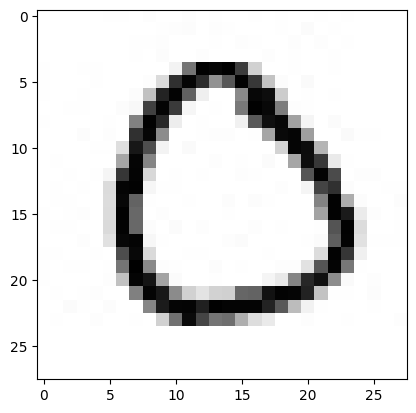

原始图像shape:  (28, 28)


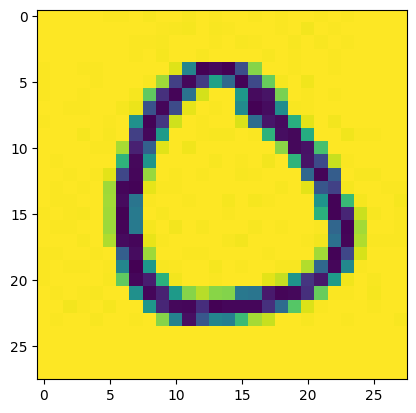

采样后图片shape:  (28, 28)


In [85]:
# 导入图像读取第三方库
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

img_path = './work/2.1data/example_0.jpg'
# 读取原始图像并显示
im = Image.open(img_path)
plt.imshow(im, cmap='gray')
plt.show()
# 将原始图像转为灰度图
im = im.convert('L')
print('原始图像shape: ', np.array(im).shape)
# 使用Image.Resampling.LANCZOS方式采样原始图片
im = im.resize((28, 28), Image.Resampling.LANCZOS)
plt.imshow(im)
plt.show()
print("采样后图片shape: ", np.array(im).shape)

In [86]:
# 读取一张本地的样例图片，转变成模型输入的格式
def load_image(img_path):
    # 从img_path中读取图像，并转为灰度图
    im = Image.open(img_path).convert('L')
    # print(np.array(im))
    im = im.resize((28, 28), Image.Resampling.LANCZOS)
    im = np.array(im).reshape(1, -1).astype(np.float32)
    # 图像归一化，保持和数据集的数据范围一致
    im = 1 - im / 255
    return im

model = MNIST()
params_file_PATH = './work/2.1data/mnist_model.pth'
img_Path = './work/2.1data/example_0.jpg'
param_dict = torch.load(params_file_PATH)
model.load_state_dict(param_dict)
model.eval()
tensor_img = load_image(img_Path)
result = model(torch.from_numpy(tensor_img))
print(result)
print("预测数字是", result.detach().numpy().astype('int32'))


tensor([[4.7061]], grad_fn=<AddmmBackward0>)
预测数字是 [[4]]


从打印结果来看，模型预测出的数字是与实际输出的图片的数字不一致。这里只是验证了一个样本的情况，如果我们尝试更多的样本，可发现许多数字图片识别结果是错误的。因此完全复用房价预测的实验并不适用于手写数字识别任务！

接下来我们会对手写数字识别实验模型进行逐一改进，直到获得令人满意的结果。